# Multimodal MRI + Voice Pipeline

This notebook runs the full multimodal pipeline:
1. MRI probability extraction
2. Voice + MRI dataset fusion
3. Early-fusion Random Forest training
4. Evaluation and artifact export

## 1. Environment Setup and Dependency Check
Install/import required libraries, verify versions, and set deterministic seeds.

In [1]:
import importlib
import json
import os
import random
import shutil
from pathlib import Path

import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

packages = [
    "pandas",
    "numpy",
    "sklearn",
    "joblib",
    "tensorflow",
    "PIL",
    "matplotlib",
    "seaborn",
]

print("Dependency check:")
for pkg in packages:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "unknown")
        print(f"  {pkg:<12} OK  version={ver}")
    except Exception as exc:
        print(f"  {pkg:<12} MISSING/ERROR -> {exc}")

print(f"\nDeterministic seed set to {SEED}")

Dependency check:
  pandas       OK  version=2.3.3
  numpy        OK  version=1.23.5
  sklearn      OK  version=1.6.1
  joblib       OK  version=1.5.3
  tensorflow   OK  version=2.10.0
  PIL          OK  version=11.3.0
  matplotlib   OK  version=3.9.4
  seaborn      OK  version=0.13.2

Deterministic seed set to 42


## 2. Project Paths and Runtime Configuration
Define input/output paths, class folders, image size, seed, and split ratio.

In [2]:
ROOT = Path.cwd().resolve()
if ROOT.name.lower() == "classification":
    ROOT = ROOT.parent

CLASSIFICATION_DIR = ROOT / "classification"
VOICE_CSV = ROOT / "_training_dataset_speech.csv"
MRI_IMAGE_ROOT = ROOT / "MRI-data" / "Combined Dataset" / "train"
MRI_MODEL_PATH = ROOT / "alzheimer_model.h5"
MRI_CLASS_DIRS = ["No Impairment", "Very Mild Impairment", "Mild Impairment", "Moderate Impairment"]

MRI_FEATURE_CSV = CLASSIFICATION_DIR / "mri_feature_table.csv"
MULTIMODAL_DATASET_CSV = CLASSIFICATION_DIR / "multimodal_training_dataset.csv"
MULTIMODAL_OUTPUT_DIR = ROOT / "model_artifacts" / "multimodal"
BACKEND_MULTIMODAL_DIR = ROOT / "backend" / "model_artifacts" / "multimodal"

TEST_SIZE = 0.2
SEED = 42

MULTIMODAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BACKEND_MULTIMODAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"VOICE_CSV: {VOICE_CSV}")
print(f"MRI_IMAGE_ROOT: {MRI_IMAGE_ROOT}")
print(f"MRI_MODEL_PATH: {MRI_MODEL_PATH}")

ROOT: E:\ML\MRI_pause_Classification
VOICE_CSV: E:\ML\MRI_pause_Classification\_training_dataset_speech.csv
MRI_IMAGE_ROOT: E:\ML\MRI_pause_Classification\MRI-data\Combined Dataset\train
MRI_MODEL_PATH: E:\ML\MRI_pause_Classification\alzheimer_model.h5


## 3. Load Voice Features and MRI Model Inputs
Load voice CSV, validate schema, and verify MRI input availability.

In [3]:
import pandas as pd

required_voice_cols = {
    "patient_id",
    "diagnosis",
    "diagnosis_name",
    "pause_count",
    "total_speech_time",
    "total_pause_time",
    "mean_word_duration",
    "speech_rate_wpm",
    "pause_per_word_ratio",
}

voice_df = pd.read_csv(VOICE_CSV)
missing = required_voice_cols - set(voice_df.columns)
if missing:
    raise ValueError(f"Voice CSV missing required columns: {sorted(missing)}")

print("Voice class distribution:")
print(voice_df["diagnosis_name"].value_counts(dropna=False))
print(f"\nMRI model exists: {MRI_MODEL_PATH.exists()}")
print(f"MRI image root exists: {MRI_IMAGE_ROOT.exists()}")
for class_dir in MRI_CLASS_DIRS:
    print(f"  {class_dir:<22} -> {(MRI_IMAGE_ROOT / class_dir).exists()}")

voice_df.head()

Voice class distribution:
diagnosis_name
MCI        658
Control    590
Name: count, dtype: int64

MRI model exists: True
MRI image root exists: False
  No Impairment          -> False
  Very Mild Impairment   -> False
  Mild Impairment        -> False
  Moderate Impairment    -> False


,pause_count,total_speech_time,total_pause_time,mean_word_duration,speech_rate_wpm,pause_per_word_ratio,patient_id,diagnosis,diagnosis_name
0,1296,471.868,170.797,0.2065,290.56,0.8786,control_aug_0001_01-2,0,Control
1,1126,402.152,127.223,0.2146,279.56,0.8361,control_aug_0002_01-3,0,Control
2,866,329.395,122.152,0.2182,275.04,0.8811,control_aug_0003_02-1,0,Control
3,775,306.583,112.354,0.2272,264.12,0.8246,control_aug_0004_02-2,0,Control
4,618,240.814,94.004,0.2143,279.95,0.8204,control_aug_0005_03-1,0,Control


## 4. Extract MRI Probability Features Table
Run MRI model across class folders and save classification/mri_feature_table.csv.

In [38]:
import importlib
import sys

sys.path.insert(0, str(CLASSIFICATION_DIR))

import mri_feature_extractor
importlib.reload(mri_feature_extractor)
from mri_feature_extractor import build_mri_feature_table

mri_feature_df = build_mri_feature_table(
    image_root=str(MRI_IMAGE_ROOT),
    model_path=str(MRI_MODEL_PATH),
    class_dirs=MRI_CLASS_DIRS,
    output_csv=str(MRI_FEATURE_CSV),
)

print(f"Saved MRI features: {MRI_FEATURE_CSV}")
print(f"Rows: {len(mri_feature_df)}")
mri_feature_df.head()

Saved MRI features: E:\ML\silero-python\classification\mri_feature_table.csv
Rows: 10240


,mri_image_path,mri_source_class,mri_pred_class_idx,mri_prob_mild_impairment,mri_prob_moderate_impairment,mri_prob_no_impairment,mri_prob_very_mild_impairment
0,E:\ML\silero-python\Alzheimers-Disease-Classif...,No Impairment,3,0.048872,2.924724e-06,0.253970,0.697155
1,E:\ML\silero-python\Alzheimers-Disease-Classif...,No Impairment,2,0.000016,2.599641e-14,0.999682,0.000302
2,E:\ML\silero-python\Alzheimers-Disease-Classif...,No Impairment,2,0.000029,5.571634e-10,0.999815,0.000156
3,E:\ML\silero-python\Alzheimers-Disease-Classif...,No Impairment,2,0.000001,5.226460e-08,0.999838,0.000161
4,E:\ML\silero-python\Alzheimers-Disease-Classif...,No Impairment,2,0.000004,4.764025e-08,0.994327,0.005669


## 5. Build Multimodal Fusion Dataset
Fuse voice rows with MRI probability rows using mapped diagnosis classes and stable grouped split.

In [4]:
from build_multimodal_dataset import build_multimodal_dataset

multimodal_df = build_multimodal_dataset(
    voice_csv=str(VOICE_CSV),
    mri_feature_csv=str(MRI_FEATURE_CSV),
    output_csv=str(MULTIMODAL_DATASET_CSV),
    test_size=TEST_SIZE,
    seed=SEED,
)

print(f"Saved multimodal dataset: {MULTIMODAL_DATASET_CSV}")
print(f"Rows: {len(multimodal_df)}")
multimodal_df.head()

Saved multimodal dataset: E:\ML\MRI_pause_Classification\classification\multimodal_training_dataset.csv
Rows: 1248


,pause_count,total_speech_time,total_pause_time,mean_word_duration,speech_rate_wpm,pause_per_word_ratio,patient_id,diagnosis,diagnosis_name,canonical_patient_id,target_mri_class,mri_prob_mild_impairment,mri_prob_moderate_impairment,mri_prob_no_impairment,mri_prob_very_mild_impairment,mri_image_path,mri_source_class,pairing_strategy,target_4class,split
0,1296,471.868,170.797,0.2065,290.56,0.8786,control_aug_0001_01-2,0,Control,01-2,No Impairment,5.442312e-04,3.641196e-06,0.950246,0.049206,E:\ML\silero-python\Alzheimers-Disease-Classif...,No Impairment,diagnosis_level_random,2,train
1,1126,402.152,127.223,0.2146,279.56,0.8361,control_aug_0002_01-3,0,Control,01-3,No Impairment,1.051429e-02,3.103110e-09,0.942246,0.047240,E:\ML\silero-python\Alzheimers-Disease-Classif...,No Impairment,diagnosis_level_random,2,train
2,866,329.395,122.152,0.2182,275.04,0.8811,control_aug_0003_02-1,0,Control,02-1,No Impairment,3.356242e-07,1.455295e-11,0.999989,0.000011,E:\ML\silero-python\Alzheimers-Disease-Classif...,No Impairment,diagnosis_level_random,2,train
3,775,306.583,112.354,0.2272,264.12,0.8246,control_aug_0004_02-2,0,Control,02-2,No Impairment,3.945857e-03,2.149028e-06,0.974024,0.022028,E:\ML\silero-python\Alzheimers-Disease-Classif...,No Impairment,diagnosis_level_random,2,test
4,618,240.814,94.004,0.2143,279.95,0.8204,control_aug_0005_03-1,0,Control,03-1,No Impairment,8.833023e-04,1.117128e-07,0.998316,0.000800,E:\ML\silero-python\Alzheimers-Disease-Classif...,No Impairment,diagnosis_level_random,2,train


## 6. Validate Split, Grouping, and Label Mapping
Check train/test group leakage, mapping validity, nulls, and split class balance.

In [5]:
train_groups = set(multimodal_df.loc[multimodal_df["split"] == "train", "canonical_patient_id"])
test_groups = set(multimodal_df.loc[multimodal_df["split"] == "test", "canonical_patient_id"])
leakage = train_groups.intersection(test_groups)

print(f"Group leakage count: {len(leakage)}")
print("Target_4class distribution:")
print(multimodal_df["target_4class"].value_counts(dropna=False).sort_index())

print("\nNulls per column (top 20):")
print(multimodal_df.isna().sum().sort_values(ascending=False).head(20))

print("\nClass counts by split:")
print(
    multimodal_df.groupby(["split", "target_4class"]).size().unstack(fill_value=0)
)

Group leakage count: 0
Target_4class distribution:
target_4class
2    590
3    658
Name: count, dtype: int64

Nulls per column (top 20):
pause_count                      0
total_speech_time                0
target_4class                    0
pairing_strategy                 0
mri_source_class                 0
mri_image_path                   0
mri_prob_very_mild_impairment    0
mri_prob_no_impairment           0
mri_prob_moderate_impairment     0
mri_prob_mild_impairment         0
target_mri_class                 0
canonical_patient_id             0
diagnosis_name                   0
diagnosis                        0
patient_id                       0
pause_per_word_ratio             0
speech_rate_wpm                  0
mean_word_duration               0
total_pause_time                 0
split                            0
dtype: int64

Class counts by split:
target_4class    2    3
split                  
test           130   85
train          460  573


## 7. Train Early-Fusion Random Forest (Group-Aware CV)
Run grouped CV and fit the final model on the training split.

In [6]:
from train_multimodal_random_forest import train_multimodal_model

train_multimodal_model(
    dataset_csv=str(MULTIMODAL_DATASET_CSV),
    output_dir=str(MULTIMODAL_OUTPUT_DIR),
    seed=SEED,
)

MULTIMODAL RANDOM FOREST TRAINING COMPLETE
Model: E:\ML\MRI_pause_Classification\model_artifacts\multimodal\multimodal_rf_model.pkl
Features: E:\ML\MRI_pause_Classification\model_artifacts\multimodal\multimodal_feature_names.pkl
Report: E:\ML\MRI_pause_Classification\model_artifacts\multimodal\multimodal_training_report.json
CV accuracy mean: 0.9275
Test weighted F1: 0.9111


## 8. Evaluate Test Metrics and Confusion Matrix
Load training report and render compact metric and confusion matrix views.

                      metric     value
0           cv_accuracy_mean  0.927502
1           cv_f1_macro_mean  0.926750
2        cv_f1_weighted_mean  0.927652
3  cv_balanced_accuracy_mean  0.929096


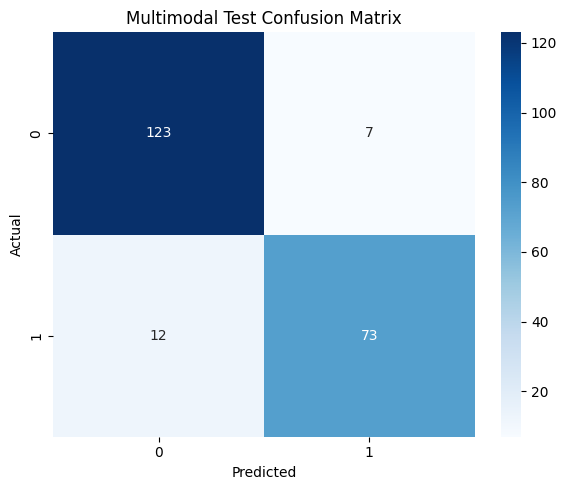

,precision,recall,f1-score,support
2,0.911111,0.946154,0.928302,130.000000
3,0.912500,0.858824,0.884848,85.000000
accuracy,0.911628,0.911628,0.911628,0.911628
macro avg,0.911806,0.902489,0.906575,215.000000
weighted avg,0.911660,0.911628,0.911123,215.000000


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

report_path = MULTIMODAL_OUTPUT_DIR / "multimodal_training_report.json"
with open(report_path, "r", encoding="utf-8") as f:
    report_json = json.load(f)

metrics_table = pd.DataFrame(
    {
        "metric": ["cv_accuracy_mean", "cv_f1_macro_mean", "cv_f1_weighted_mean", "cv_balanced_accuracy_mean"],
        "value": [
            report_json["cv_accuracy_mean"],
            report_json["cv_f1_macro_mean"],
            report_json["cv_f1_weighted_mean"],
            report_json["cv_balanced_accuracy_mean"],
        ],
    }
)
print(metrics_table)

cm = np.array(report_json["test_confusion_matrix"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Multimodal Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

per_class = pd.DataFrame(report_json["test_classification_report"]).T
per_class

## 9. Save Model, Feature Names, and Training Report
Confirm artifacts and copy model files to backend/model_artifacts/multimodal.

In [9]:
model_file = MULTIMODAL_OUTPUT_DIR / "multimodal_rf_model.pkl"
features_file = MULTIMODAL_OUTPUT_DIR / "multimodal_feature_names.pkl"
report_file = MULTIMODAL_OUTPUT_DIR / "multimodal_training_report.json"

for p in [model_file, features_file, report_file]:
    print(f"{p.name:<36} exists={p.exists()}")

if model_file.exists():
    shutil.copy2(model_file, BACKEND_MULTIMODAL_DIR / model_file.name)
if features_file.exists():
    shutil.copy2(features_file, BACKEND_MULTIMODAL_DIR / features_file.name)
if report_file.exists():
    shutil.copy2(report_file, BACKEND_MULTIMODAL_DIR / report_file.name)

print(f"\nCopied artifacts into: {BACKEND_MULTIMODAL_DIR}")
list(BACKEND_MULTIMODAL_DIR.iterdir())

multimodal_rf_model.pkl              exists=True
multimodal_feature_names.pkl         exists=True
multimodal_training_report.json      exists=True

Copied artifacts into: E:\ML\silero-python\backend\model_artifacts\multimodal


[WindowsPath('E:/ML/silero-python/backend/model_artifacts/multimodal/multimodal_feature_names.pkl'),
 WindowsPath('E:/ML/silero-python/backend/model_artifacts/multimodal/multimodal_rf_model.pkl'),
 WindowsPath('E:/ML/silero-python/backend/model_artifacts/multimodal/multimodal_training_report.json')]

## 10. Backend Multimodal Readiness Check
Load backend multimodal artifacts and confirm feature count.

In [10]:
import sys

BACKEND_DIR = ROOT / "backend"
sys.path.insert(0, str(BACKEND_DIR))

try:
    from predict import get_multimodal_artifacts

    mm_model, mm_features = get_multimodal_artifacts()
    print(f"Backend multimodal model loaded: {type(mm_model).__name__}")
    print(f"Backend multimodal feature count: {len(mm_features)}")
except Exception as exc:
    print(f"Backend multimodal readiness check failed: {exc}")

Backend multimodal model loaded: Pipeline
Backend multimodal feature count: 10


## 11. True New-Data Inference (External Files)
This section predicts on external input files directly (not the internal train/test split rows).

Workflow:
1. Load one CHA transcript and one MRI image from external paths.
2. Extract voice features from CHA.
3. Extract MRI probability features from image.
4. Build the fused feature vector in saved training feature order.
5. Run the saved multimodal model and print probabilities.

A mini-batch example is also included for quick repeated new-data checks.

In [23]:
from pathlib import Path

import pandas as pd

# External new-data inputs (editable)
NEW_CHA_FILE = ROOT / "Delaware" / "MCI" / "11-1.cha"
NEW_MRI_FILE = ROOT / "Alzheimers-Disease-Classification" / "Combined Dataset" / "test" / "Very Mild Impairment" / "1 (35).jpg"

if not NEW_CHA_FILE.exists():
    raise FileNotFoundError(f"CHA file not found: {NEW_CHA_FILE}")
if not NEW_MRI_FILE.exists():
    raise FileNotFoundError(f"MRI file not found: {NEW_MRI_FILE}")

from feature_extraction import extract_features_from_lines
from predict import extract_mri_probability_features, MULTIMODAL_LABELS

with open(NEW_CHA_FILE, "r", encoding="utf-8") as f:
    new_cha_lines = f.readlines()

voice_features = extract_features_from_lines(new_cha_lines)
if voice_features is None:
    raise RuntimeError("Could not extract voice features from NEW_CHA_FILE")

with open(NEW_MRI_FILE, "rb") as f:
    new_mri_bytes = f.read()
mri_features = extract_mri_probability_features(new_mri_bytes)

fused_features = {**voice_features, **mri_features}
missing_for_model = [c for c in mm_features if c not in fused_features]
if missing_for_model:
    raise ValueError(f"Missing required fusion features: {missing_for_model}")

X_new = pd.DataFrame([fused_features])[mm_features].astype(float)
new_pred = int(mm_model.predict(X_new)[0])
new_proba = mm_model.predict_proba(X_new)[0]

print("External new-data prediction")
print(f"  CHA file: {NEW_CHA_FILE}")
print(f"  MRI file: {NEW_MRI_FILE}")
print(f"  Predicted class: {new_pred} -> {MULTIMODAL_LABELS.get(new_pred, str(new_pred))}")
print("  Class probabilities:")
for idx, label in MULTIMODAL_LABELS.items():
    if idx < len(new_proba):
        print(f"    {idx}: {label:<24} {new_proba[idx]*100:6.2f}%")

External new-data prediction
  CHA file: E:\ML\silero-python\Delaware\MCI\11-1.cha
  MRI file: E:\ML\silero-python\Alzheimers-Disease-Classification\Combined Dataset\test\Very Mild Impairment\1 (35).jpg
  Predicted class: 3 -> Very Mild Impairment
  Class probabilities:
    0: Mild Impairment           14.94%
    1: Moderate Impairment       85.06%
